In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
import fem_pendulum
import fem_pendulum_torque

In [2]:
#model = fem_pendulum.FEMPendulum(name="Pendulum", group="Plant")
model = fem_pendulum_torque.FEMPendulum(name="Pendulum", group="Plant")

model._with_contact= False
model._use_gravity = False

model.init_params.angular_position_deg = 0
model.init_params.angular_velocity = 0
model.init_params.drive_torque = 100

model.initialize(0.0)
#model.visualize_state()
model.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
# Analytical solution
I = model.inertia
m = model.mass
q0 = np.deg2rad(model.init_params.angular_position_deg)
omega0 = model.init_params.angular_velocity

# q(t+1) = q(t) + omega(t)*dt + 0.5*alpha(t)*dt^2

def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

In [4]:
t = 0.0
dt = 0.01
t_end = 1
model.sim_params.t_end = t_end

t_vals = [t]
q_vals = [q0]
a_vals = [omega0]
w_vals = [0.0]

q_an_vals = [q0]
w_an_vals = [omega0]
alpha_an_vals = [0.0]

torque_val = model.init_params.drive_torque
q_an = q0
omega_an = omega0

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = torque_val
    else:
        torque = -torque_val
    
    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)
    
    # Perform simulation step
    model.set_inputs({'torque':torque}, t)
    model.do_step(t, dt)
    t_next = t + dt

    a_vals.append(model.outputs['alpha'].get())
    w_vals.append(model.outputs['omega'].get())
    q_vals.append(model.outputs['q'].get())

    q_an_vals.append(q_an)
    w_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

    t_vals.append(t_next)
    t = t_next

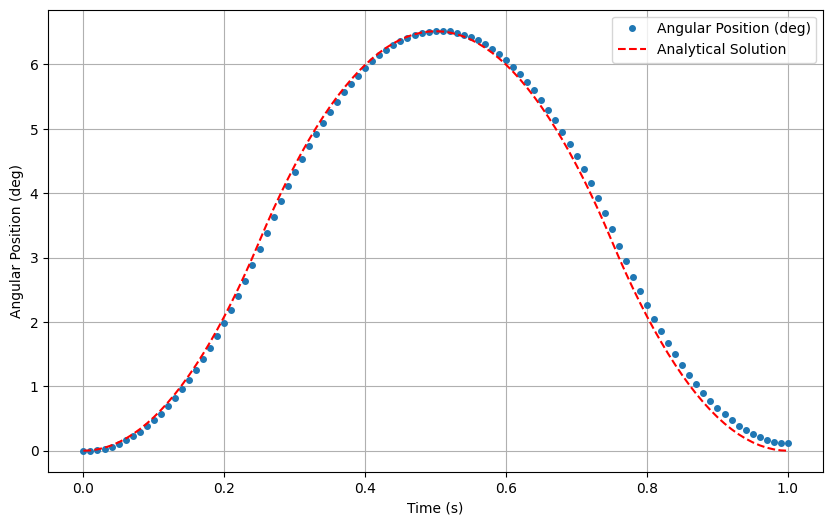

Final Angle (deg): 0.11410830230666547 deg


In [5]:
marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}

plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), label='Angular Position (deg)', **fem_style)
plt.plot(t_vals, np.rad2deg(q_an_vals), label='Analytical Solution', linestyle='--', color='r')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (deg)')
plt.grid()
plt.legend()
plt.show()

print(f"Final Angle (deg): {np.rad2deg(model.outputs['q'].get())}")

---------------------